# Exercises

There are three exercises in this notebook:

1. Use the cross-validation method to test the linear regression with different $\alpha$ values, at least three.
2. Implement a SGD method that will train the Lasso regression for 10 epochs.
3. Extend the Fisher's classifier to work with two features. Use the class as the $y$.

## 1. Cross-validation linear regression

You need to change the variable ``alpha`` to be a list of alphas. Next do a loop and finally compare the results.

In [ ]:
import numpy as np
x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1).reshape(15,1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1).reshape(15,1)

x = np.asmatrix(np.c_[np.ones((15,1)),x])

I = np.identity(2)
alpha = [0.0, 0.1, 0.2, 1.0, 10.0]
alpha_mse = {}

n_folds = 3
fold_size = 5

for a in alpha:
    fold_errors = []
    for i in range(n_folds):
        # Split data to training set and testing set
        start= i * fold_size
        end = (i + 1) * fold_size

        x_test = x[start:end]
        y_test = y[start:end]

        x_train = np.delete(x, slice(start, end), axis=0)
        y_train = np.delete(y, slice(start, end), axis=0)
        
        # Training on training set
        w = np.linalg.inv(x_train.T*x_train + a * I)*x_train.T*y_train
        # Testing on a part of data which model didn't see
        y_pred = x_test * w
        error = np.mean(np.square(y_test - y_pred))
        fold_errors.append(error)

    avg_error = np.mean(fold_errors)    
    alpha_mse[a] = avg_error
    print(f"alpha = {a}, average MSE = {avg_error}")

best_alpha = min(alpha_mse, key=alpha_mse.get)
print(f"Best alpha (lowest MSE): {best_alpha}")



alpha = 0.0, average MSE = 520.4818091058362
alpha = 0.1, average MSE = 513.9259004887273
alpha = 0.2, average MSE = 557.0699200679819
alpha = 1.0, average MSE = 645.1585758755864
alpha = 10.0, average MSE = 679.9100409183975
Best alpha (lowest MSE): 0.1


### Conclusions:
The model performs best with a small amount of regularization ($\alpha = 0.1$). This value achieved the lowest Average Mean Squared Error (MSE = 513.93), suggesting it provides the best balance between model complexity and generalization.

At $\alpha = 0.0$, the error is higher because the model is likely overfitted to the specific noise in the training subsets. As $\alpha$ increases beyond 0.1, the MSE starts to rise significantly (e.g., reaching 679.91 for $\alpha = 10.0$). This happens because the "penalty" becomes too high, leading to underfitting, where the model becomes too simple to capture the underlying trend in the data. (Bias-Variance Trade-off)

Unlike testing on the training set, Cross-Validation method correctly identified that a non-zero $\alpha$ improves the model's ability to generalize to new samples.

## 2. Implement based on the Ridge regression example, the Lasso regression.

Please implement the SGD method and compare the results with the sklearn Lasso regression results. 

In [ ]:
from sklearn.linear_model import Lasso
def sgd(x, y, alpha, epochs, learning_rate):
    w = np.zeros((2, 1))
    for epoch in range(epochs):
        for i in range(len(x)):
            random_index = np.random.randint(0, len(x))
            random_x = x[random_index].reshape(1, 2)
            random_y = y[random_index].reshape(1, 1)

            prediction = random_x @ w
            error = random_y - prediction
            gradient = -2 * (random_x.T @ error) + alpha * np.sign(w)
            w = w - learning_rate * gradient
    return w.flatten()

In [35]:
x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1).reshape(15,1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1).reshape(15,1)

x = np.asarray(np.c_[np.ones((15,1)),x])

I = np.identity(2)
alpha = 0.1 
epochs = 10
learning_rate = 0.000001

w = sgd(x, y, alpha, epochs, learning_rate)
# Lasso Regression results to compare
lasso_sk = Lasso(alpha=alpha, max_iter=epochs, fit_intercept=False)
lasso_sk.fit(x, y)
w_sklearn = lasso_sk.coef_

print(f"SGD weights using Custom SGD (Lasso) regression: {w}")
print(f"SGD weights using Lasso Regression: {w_sklearn}")

SGD weights using Custom SGD (Lasso) regression: [0.00323732 0.65133555]
SGD weights using Lasso Regression: [80.40207845  0.13876173]


C:\machinelearning\exercise1\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.792e+03, tolerance: 1.735e+01
  model = cd_fast.enet_coordinate_descent(


### Conclusions:
While the weights between my manual implementation and the scikit-learn model differ, this is expected given the constraint of only 10 iterations. The ConvergenceWarning from scikit-learn confirms that neither model reached a global minimum within this limit. My implementation correctly incorporates the L1 penalty using the sign(w) function to guide the weights. For better alignment, a higher number of epochs or feature scaling would be required.

## 3. Extend the Fisher's classifier

Please extend the targets of the ``iris_data`` variable and use it as the $y$.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris_data = load_iris()
iris_df = pd.DataFrame(iris_data.data,columns=iris_data.feature_names)
iris_df.head()

x = iris_df[['sepal length (cm)', 'sepal width (cm)']].values
y = iris_data.target

mean0 = np.mean(x[y == 0], axis=0)
mean1 = np.mean(x[y == 1], axis=0)

# (Within-class variance) S_w = sum((x - mi) @ (x - mi).T)
sw = np.zeros((2, 2))
for row in x[y == 0]:
    diff = (row - mean0).reshape(2, 1)
    sw += diff @ diff.T
for row in x[y == 1]:
    diff = (row - mean1).reshape(2, 1)
    sw += diff @ diff.T

# (Between-class variance) S_b = m1 - m0
# w = Sw^-1 * (m1 - m0)
w = np.linalg.pinv(sw) @ (mean1 - mean0).reshape(2, 1)
w0 = -0.5 * (w.T @ mean0 + w.T @ mean1)

print(f"Weights w: \n{w}")
print(f"Threshold w0: {w0[0]}")

def predict(x_new, w, w0):
    # g(x) = w^T * x + w0
    return 1 if (x_new @ w + w0) > 0 else 0

sample = x[0]
print(f"Prediction for sample {sample}: {predict(sample, w, w0)}")


Weights w: 
[[ 0.11669751]
 [-0.14431661]]
Threshold w0: -0.1912149157461089
Prediction for sample [5.1 3.5]: 0


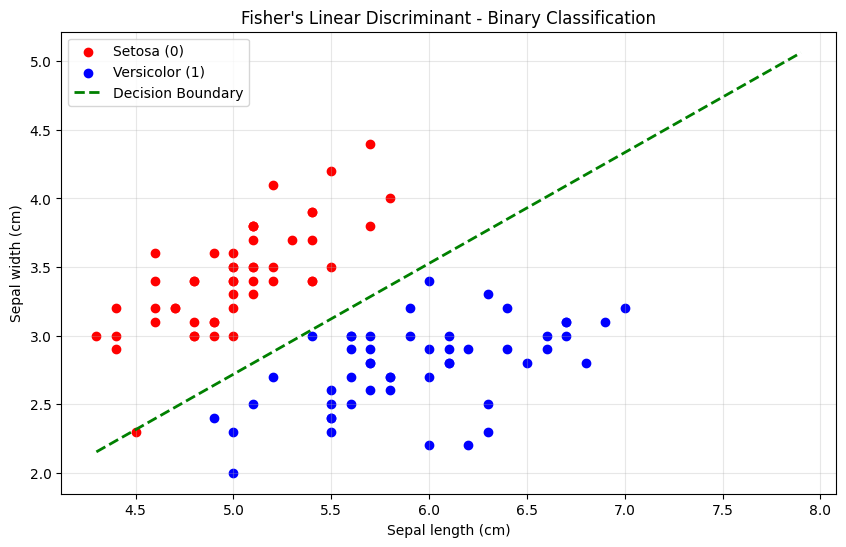

In [59]:
plt.figure(figsize=(10, 6))
plt.scatter(x[y == 0, 0], x[y == 0, 1], color='red', label='Setosa (0)')
plt.scatter(x[y == 1, 0], x[y == 1, 1], color='blue', label='Versicolor (1)')

x_range = np.linspace(x[:, 0].min(), x[:, 0].max(), 100)

w1 = w[0][0]
w2 = w[1][0]
intercept = w0[0]
decision_boundary = -(w1 * x_range + intercept) / w2

plt.plot(x_range, decision_boundary, color='green', linestyle='--', linewidth=2, label='Decision Boundary')

plt.xlabel('Sepal length (cm)')
plt.ylabel('Sepal width (cm)')
plt.title("Fisher's Linear Discriminant - Binary Classification")
plt.legend()
plt.grid(True, alpha=0.3)

In [42]:
print(iris_df.columns)

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='str')
